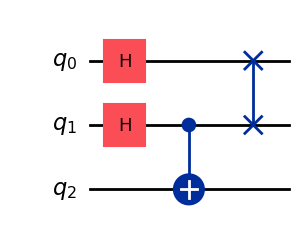

In [17]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
from qiskit_ibm_runtime import SamplerV2, Batch
from qiskit_aer.primitives import EstimatorV2
 
from qiskit_addon_cutting.instructions import Move, CutWire
from qiskit_addon_cutting import (
    partition_problem,
    generate_cutting_experiments,
    cut_wires,
    expand_observables,
    reconstruct_expectation_values,
)
 
 
qc_0 = QuantumCircuit(3)
for i in range(2):
    qc_0.h(i)

qc_0.cx(1,2)
qc_0.swap(0,1)

 
# Define observable
observable = SparsePauliOp(["ZII", "IZI"])
 
# Draw circuit
qc_0.draw("mpl")

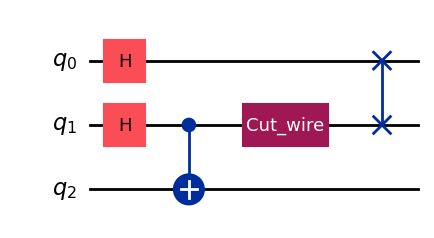

In [18]:
qc_1 = QuantumCircuit(3)
for i in range(2):
    qc_1.h(i)

qc_1.cx(1,2)
qc_1.append(CutWire(), [1])
qc_1.swap(0,1)
 
qc_1.draw("mpl")

Expanded Observable: ['ZIII', 'IZII']


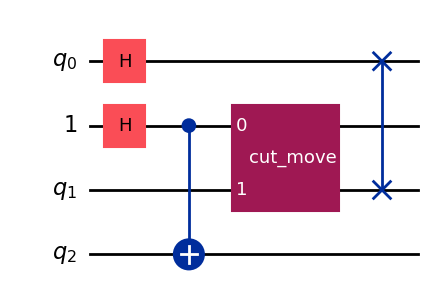

In [19]:
# Transform CutWire instructions to Move instructions
qc_2 = cut_wires(qc_1)
 
# Expand the observable to match the new circuit size
expanded_observable = expand_observables(observable.paulis, qc_0, qc_2)
print(f"Expanded Observable: {expanded_observable}")
qc_2.draw("mpl")

Subobservables to measure: 
{0: PauliList(['II', 'ZI']), 1: PauliList(['ZI', 'II'])}

Sampling overhead: 16.0


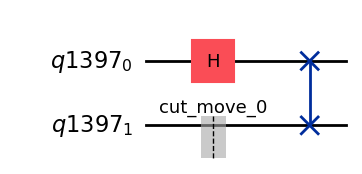

In [20]:
partitioned_problem = partition_problem(
    circuit=qc_2,
    observables=expanded_observable,
)
subcircuits = partitioned_problem.subcircuits
subobservables = partitioned_problem.subobservables
bases = partitioned_problem.bases
 
print(f"Subobservables to measure: \n{subobservables}\n")
print(f"Sampling overhead: {np.prod([basis.overhead for basis in bases])}")
subcircuits[0].draw("mpl")

In [22]:
# Generate subexperiments
subexperiments, coefficients = generate_cutting_experiments(
    circuits=subcircuits, observables=subobservables, num_samples=np.inf
)

In [37]:
from qiskit import qpy
import os

os.makedirs("saved_data", exist_ok=True)

for key, circuits in subexperiments.items():
    for i, circuit in enumerate(circuits):
        with open(f"saved_data/group_{key}_{i}.qpy", "wb") as f:
            qpy.dump(circuits, f)


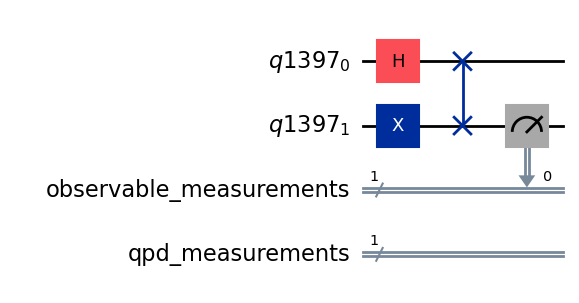

In [58]:
subexperiments[0][1].draw()

In [38]:
import os
from collections import defaultdict
from qiskit import qpy

folder = "saved_data"

circuits_dict = defaultdict(list)

for fname in sorted(os.listdir(folder)):
    if not fname.endswith(".qpy"):
        continue

    # filename format: group_<key>_<index>.qpy
    _, key, idx = fname.replace(".qpy", "").split("_")
    key = int(key)

    with open(os.path.join(folder, fname), "rb") as f:
        circuits = qpy.load(f)   # returns a list
        circuits_dict[key].append(circuits[0])  # single circuit per file


In [41]:
# Set a backend to use and transpile the subexperiments
backend = FakeManilaV2()
pass_manager = generate_preset_pass_manager(
    optimization_level=1, backend=backend
)
isa_subexperiments = {
    label: pass_manager.run(partition_subexpts)
    for label, partition_subexpts in circuits_dict.items()
}
 
# Submit each partition's subexperiments to the Qiskit Runtime Sampler
# primitive, in a single batch so that the jobs will run back-to-back.
with Batch(backend=backend) as batch:
    sampler = SamplerV2(mode=batch)
    jobs = {
        label: sampler.run(subsystem_subexpts, shots=2**12)
        for label, subsystem_subexpts in isa_subexperiments.items()
    }
    # Retrieve results
    results = {label: job.result() for label, job in jobs.items()}

In [42]:
reconstructed_expval_terms = reconstruct_expectation_values(
    results,
    coefficients,
    subobservables,
)
# Apply the coefficients of the original observable
reconstructed_expval = np.dot(reconstructed_expval_terms, observable.coeffs)
 
 
# Compute the exact expectation value using the `qiskit_aer` package.
estimator = EstimatorV2()
exact_expval = estimator.run([(qc_0, observable)]).result()[0].data.evs
print(
    f"Reconstructed expectation value: {np.real(np.round(reconstructed_expval, 3))}"
)
print(f"Exact expectation value: {np.round(exact_expval, 3)}")
print(
    f"Error in estimation: {np.real(np.round(reconstructed_expval-exact_expval, 3))}"
)
print(
    f"Relative error in estimation: {np.real(np.round((reconstructed_expval-exact_expval) / exact_expval, 8))}"
)

Reconstructed expectation value: 0.063
Exact expectation value: 0.0
Error in estimation: 0.063
Relative error in estimation: inf


/var/folders/l8/z9twtlsx6815m7383kbwwymm0000gn/T/ipykernel_62428/3468888020.py:21: RuntimeWarning: divide by zero encountered in divide
  f"Relative error in estimation: {np.real(np.round((reconstructed_expval-exact_expval) / exact_expval, 8))}"
/var/folders/l8/z9twtlsx6815m7383kbwwymm0000gn/T/ipykernel_62428/3468888020.py:21: RuntimeWarning: invalid value encountered in divide
  f"Relative error in estimation: {np.real(np.round((reconstructed_expval-exact_expval) / exact_expval, 8))}"
